# 01 — Data Exploration & First Correlations

Loads the four pipeline outputs (`data/*.parquet`), does a quick sanity pass on each, aligns them onto a common weekly grid, and runs the first correlation matrix from `docs/PRICE_DISCOVERY.md`'s TODO list:

> Correlation matrix: HDD vs. price, storage vs. price, COT extremes vs. 2-week forward returns

This is a starting point, not a finished analysis — see the **Next steps** cell at the bottom.

## Setup

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

DATA_DIR = "../data"

## Load the four datasets

Straight `read_parquet` — no transforms yet, just what each fetcher wrote.

In [3]:
futures = pd.read_parquet(f"{DATA_DIR}/futures.parquet")
storage = pd.read_parquet(f"{DATA_DIR}/eia_storage.parquet")
weather = pd.read_parquet(f"{DATA_DIR}/degree_days.parquet")
cot = pd.read_parquet(f"{DATA_DIR}/cftc_cot.parquet")

for name, df in [("futures", futures), ("storage", storage), ("weather", weather), ("cot", cot)]:
    print(f"{name}: {df.shape}")

futures: (6536, 6)
storage: (103, 5)
weather: (105, 3)
cot: (104, 17)


## Exploration

Each dataset has its own index/date column and cadence:
- `futures` — indexed by `Date`, one row per ticker per day (`NG=F` is the front-month continuous contract; the rest are monthly CME contract codes)
- `storage` — one row per week (`date`), Thursday-anchored per EIA's release schedule
- `weather` — one row per ISO week (`week_start`, Monday-anchored)
- `cot` — one row per week (`date`), CFTC's Tuesday-as-of / Friday-release schedule

None of these line up on the same day of week, so we'll need to align them before comparing.

In [4]:
futures.index.name, futures["ticker"].unique()

('Date',
 <ArrowStringArray>
 [     'NG=F', 'NGH27.NYM', 'NGQ26.NYM', 'NGN27.NYM', 'NGK27.NYM', 'NGV26.NYM', 'NGZ26.NYM', 'NGJ27.NYM', 'NGM27.NYM', 'NGU26.NYM',
  'NGX26.NYM', 'NGG27.NYM', 'NGF27.NYM']
 Length: 13, dtype: str)

In [5]:
front_month = futures[futures["ticker"] == "NG=F"].sort_index()
front_month[["Close", "Volume"]].tail()

Price,Close,Volume
Date,,
2026-06-30,3.275,207986
2026-07-01,3.220,122894
2026-07-02,3.196,137589
2026-07-06,3.245,137589
2026-07-07,3.279,1064


In [6]:
storage.tail()

,date,working_gas_bcf,series_id,net_change_bcf,value_5yr_avg
98,2026-05-29,2578,NG.NW2_EPG0_SWO_R48_BCF.W,95.0,2492.4
99,2026-06-05,2686,NG.NW2_EPG0_SWO_R48_BCF.W,108.0,2567.4
100,2026-06-12,2759,NG.NW2_EPG0_SWO_R48_BCF.W,73.0,2645.4
101,2026-06-19,2835,NG.NW2_EPG0_SWO_R48_BCF.W,76.0,2722.8
102,2026-06-26,2922,NG.NW2_EPG0_SWO_R48_BCF.W,87.0,2770.6


In [7]:
weather.tail()

,week_start,hdd_weekly,cdd_weekly
100,2026-06-08,3.400000,74.129167
101,2026-06-15,2.620833,54.187500
102,2026-06-22,1.683333,62.154167
103,2026-06-29,2.229167,101.216667
104,2026-07-06,0.000000,34.825000


In [8]:
cot[["date", "Open_Interest_All", "managed_money_net", "producer_net"]].tail()

,date,Open_Interest_All,managed_money_net,producer_net
99,2026-06-02,1664003,-114854,-22783
100,2026-06-09,1637740,-122617,-21073
101,2026-06-16,1644546,-84909,-28589
102,2026-06-23,1613059,-82722,-30615
103,2026-06-30,1634535,-64808,-31500


In [9]:
# Null check across all four — worth knowing before trusting any correlation
for name, df in [("futures", front_month), ("storage", storage), ("weather", weather), ("cot", cot)]:
    nulls = df.isna().sum()
    print(f"{name}:")
    print(nulls[nulls > 0] if nulls.any() else "  no nulls")

futures:
  no nulls
storage:
  no nulls
weather:
  no nulls
cot:
  no nulls


## Align to a common weekly grid

Every series gets bucketed to `week_start` = the Monday of its week, matching the convention `fetch_weather.py` already uses. `futures` is resampled from daily to weekly (last close of the week); the others are already weekly and just need their date column relabeled to the Monday.

In [10]:
def to_week_start(s: pd.Series) -> pd.Series:
    """Map a datetime Series to the Monday of its ISO week."""
    return s - pd.to_timedelta(s.dt.dayofweek, unit="D")


# Futures: resample front-month daily closes to weekly (last obs of the week)
fm = front_month.copy()
fm["week_start"] = to_week_start(fm.index.to_series())
futures_weekly = (
    fm.groupby("week_start")["Close"]
    .last()
    .rename("ng_close")
    .reset_index()
)

# Storage: relabel to week_start, keep the metrics we care about
storage_weekly = storage.copy()
storage_weekly["week_start"] = to_week_start(storage_weekly["date"])
storage_weekly["storage_vs_5yr_avg"] = (
    storage_weekly["working_gas_bcf"] - storage_weekly["value_5yr_avg"]
)
storage_weekly = storage_weekly[
    ["week_start", "working_gas_bcf", "net_change_bcf", "storage_vs_5yr_avg"]
]

# Weather: already week_start-labeled
weather_weekly = weather.copy()

# COT: relabel to week_start
cot_weekly = cot.copy()
cot_weekly["week_start"] = to_week_start(cot_weekly["date"])
cot_weekly = cot_weekly[
    ["week_start", "Open_Interest_All", "managed_money_net", "producer_net"]
]

futures_weekly.shape, storage_weekly.shape, weather_weekly.shape, cot_weekly.shape

((105, 2), (103, 4), (105, 3), (104, 4))

In [11]:
weekly = (
    futures_weekly.merge(storage_weekly, on="week_start", how="inner")
    .merge(weather_weekly, on="week_start", how="inner")
    .merge(cot_weekly, on="week_start", how="inner")
    .sort_values("week_start")
    .reset_index(drop=True)
)

print(f"{len(weekly)} aligned weekly rows, {weekly['week_start'].min().date()} to {weekly['week_start'].max().date()}")
weekly.tail()

103 aligned weekly rows, 2024-07-08 to 2026-06-22


,week_start,ng_close,working_gas_bcf,net_change_bcf,storage_vs_5yr_avg,hdd_weekly,cdd_weekly,Open_Interest_All,managed_money_net,producer_net
98,2026-05-25,3.290,2578,95.0,85.6,9.120833,44.420833,1640082,-134426,-10707
99,2026-06-01,3.229,2686,108.0,118.6,4.670833,55.187500,1664003,-114854,-22783
100,2026-06-08,3.120,2759,73.0,113.6,3.400000,74.129167,1637740,-122617,-21073
101,2026-06-15,3.233,2835,76.0,112.2,2.620833,54.187500,1644546,-84909,-28589
102,2026-06-22,3.231,2922,87.0,151.4,1.683333,62.154167,1613059,-82722,-30615


## Derived columns

Week-over-week price return, and forward returns for the COT-extremes question ("does managed money positioning predict the next 2/4 weeks of price?").

In [12]:
weekly["ng_return_1w"] = weekly["ng_close"].pct_change()
weekly["ng_return_fwd_2w"] = weekly["ng_close"].pct_change(2).shift(-2)
weekly["ng_return_fwd_4w"] = weekly["ng_close"].pct_change(4).shift(-4)

## Correlation matrix

Same-week relationships first: HDD/CDD, storage, and positioning against the NG close and its 1-week return.

In [13]:
corr_cols = [
    "ng_close",
    "ng_return_1w",
    "hdd_weekly",
    "cdd_weekly",
    "working_gas_bcf",
    "net_change_bcf",
    "storage_vs_5yr_avg",
    "managed_money_net",
    "producer_net",
]
corr = weekly[corr_cols].corr()
corr

,ng_close,ng_return_1w,hdd_weekly,cdd_weekly,working_gas_bcf,net_change_bcf,storage_vs_5yr_avg,managed_money_net,producer_net
ng_close,1.000000,0.303759,0.583704,-0.478509,-0.103252,-0.432591,-0.492055,0.345865,0.146197
ng_return_1w,0.303759,1.000000,0.074902,-0.068990,0.123856,-0.021170,0.126664,-0.094148,0.016989
hdd_weekly,0.583704,0.074902,1.000000,-0.807119,-0.163201,-0.879916,-0.392664,0.341232,0.079172
cdd_weekly,-0.478509,-0.068990,-0.807119,1.000000,0.191094,0.498997,0.520141,-0.186298,-0.285144
working_gas_bcf,-0.103252,0.123856,-0.163201,0.191094,1.000000,0.071185,0.682664,-0.390075,-0.090126
net_change_bcf,-0.432591,-0.021170,-0.879916,0.498997,0.071185,1.000000,0.210364,-0.388625,0.090033
storage_vs_5yr_avg,-0.492055,0.126664,-0.392664,0.520141,0.682664,0.210364,1.000000,-0.540623,-0.155793
managed_money_net,0.345865,-0.094148,0.341232,-0.186298,-0.390075,-0.388625,-0.540623,1.000000,-0.444653
producer_net,0.146197,0.016989,0.079172,-0.285144,-0.090126,0.090033,-0.155793,-0.444653,1.000000


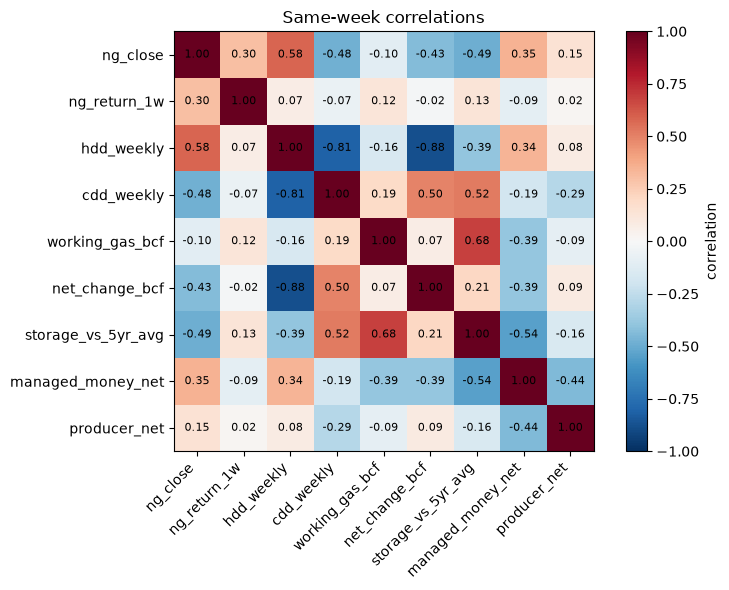

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols)), corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, label="correlation")
ax.set_title("Same-week correlations")
fig.tight_layout()

## COT extremes vs. forward returns

The TODO asks specifically about *forward* returns, not same-week — does a managed-money extreme this week predict the next 2 or 4 weeks?

In [15]:
fwd_corr = weekly[["managed_money_net", "producer_net", "ng_return_fwd_2w", "ng_return_fwd_4w"]].corr()
fwd_corr.loc[["managed_money_net", "producer_net"], ["ng_return_fwd_2w", "ng_return_fwd_4w"]]

,ng_return_fwd_2w,ng_return_fwd_4w
managed_money_net,-0.185389,-0.263043
producer_net,0.014888,-0.018949


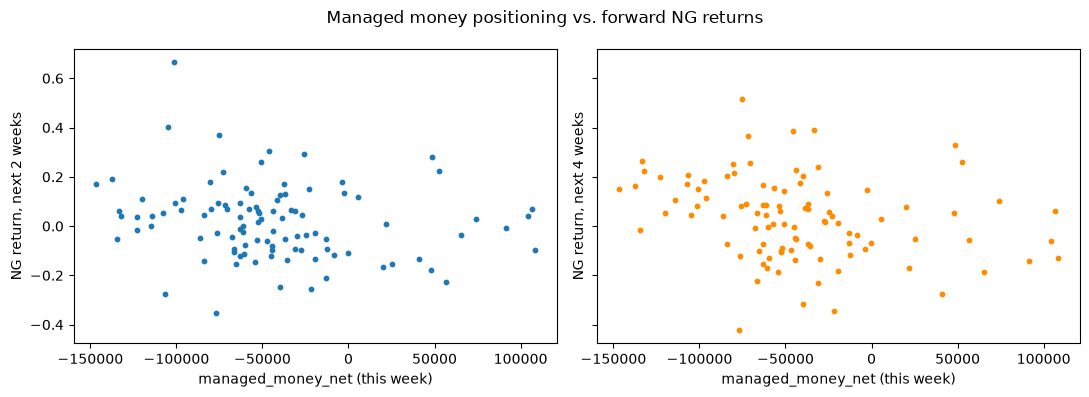

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].scatter(weekly["managed_money_net"], weekly["ng_return_fwd_2w"], s=10)
axes[0].set_xlabel("managed_money_net (this week)")
axes[0].set_ylabel("NG return, next 2 weeks")
axes[1].scatter(weekly["managed_money_net"], weekly["ng_return_fwd_4w"], s=10, color="darkorange")
axes[1].set_xlabel("managed_money_net (this week)")
axes[1].set_ylabel("NG return, next 4 weeks")
fig.suptitle("Managed money positioning vs. forward NG returns")
fig.tight_layout()

## Storage vs. 5-year average, over time

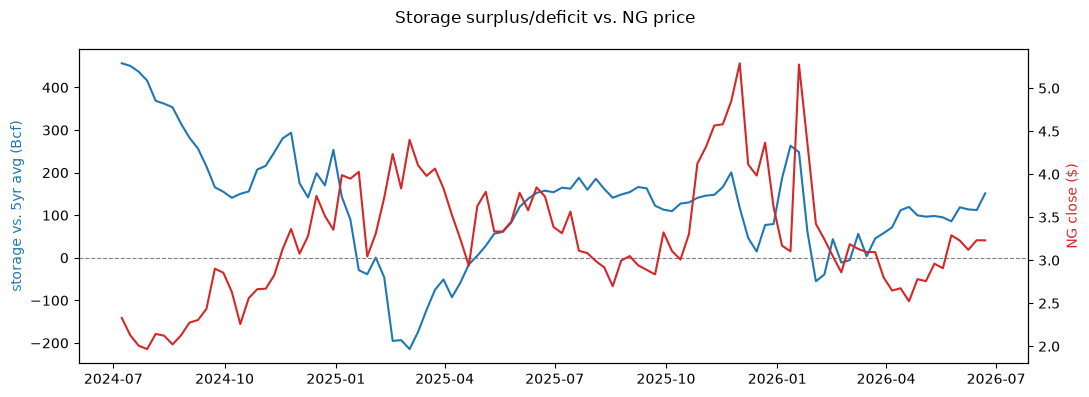

In [17]:
fig, ax1 = plt.subplots(figsize=(11, 4))
ax1.plot(weekly["week_start"], weekly["storage_vs_5yr_avg"], color="tab:blue", label="storage vs. 5yr avg (Bcf)")
ax1.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax1.set_ylabel("storage vs. 5yr avg (Bcf)", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(weekly["week_start"], weekly["ng_close"], color="tab:red", label="NG close")
ax2.set_ylabel("NG close ($)", color="tab:red")

fig.suptitle("Storage surplus/deficit vs. NG price")
fig.tight_layout()

## Next steps

Only ~2 years of weekly data (`ROLLING_YEARS = 2` in the pipeline scripts) — that's roughly 100 weekly observations, so treat any correlation here as directional, not conclusive. From `docs/PRICE_DISCOVERY.md`'s TODO list, still open:

- [ ] Seasonality decomposition — strip out the seasonal HDD/CDD pattern to see structural trends underneath
- [ ] Storage pulse metric — is storage changing faster/slower than the 5-yr average pace, not just the level?
- [ ] Term structure regime — bring in the deferred contract tickers from `futures` (currently only `NG=F` is used above) to classify contango vs. backwardation periods
- [ ] Producer hedging ratio — `producer_net / Open_Interest_All` as an implied view on forward supply

Once one of these produces a real finding, write it up as a case study in `docs/PRICE_DISCOVERY.md` and log it in `docs/LEARNING_LOG.md`.